In [1]:
import pandas as pd

In [2]:
fall = pd.read_csv("data/data100-fa23-full.csv")
spring = pd.read_csv("data/data100-sp24-full.csv")
fall.drop("email", axis = 1);
spring.drop("email", axis = 1);

In [3]:
#fall.head()

In [16]:
#spring["assignment"].value_counts()

In [17]:
#fall["assignment"].value_counts()

In [6]:
fall_na = fall["ticket_created"].isna().sum() + fall["ticket_updated"].isna().sum()
spring_na = spring["ticket_created"].isna().sum() + spring["ticket_updated"].isna().sum()
print("fall_na", fall_na, "spring_na", spring_na)

fall_na 0 spring_na 0


In [7]:
fall['time_created'] = pd.to_datetime(fall['ticket_created'])
fall['time_updated'] = pd.to_datetime(fall['ticket_updated'])

spring['time_created'] = pd.to_datetime(spring['ticket_created'])
spring['time_updated'] = pd.to_datetime(spring['ticket_updated'])

#fall[['ticket_id','time_created','time_updated']].head()

In [8]:
fall['ticket_duration'] = fall['time_updated'] - fall['time_created']
spring['ticket_duration'] = spring['time_updated'] - spring['time_created']
#fall[['ticket_duration','ticket_id','time_created','time_updated']].head()

In [9]:
fall['ticket_duration_minutes'] = fall['ticket_duration'].dt.total_seconds() / 60
spring['ticket_duration_minutes'] = spring['ticket_duration'].dt.total_seconds() /60
#fall.head()

In [10]:
# remove outliers (greater than 5 hours)
five_hrs = 60*5
fall_outlier_cond = (fall["ticket_duration_minutes"] >= five_hrs) | (fall["ticket_duration_minutes"] < 0)
fall_clean = fall[~fall_outlier_cond]

spring_outlier_cond = (spring["ticket_duration_minutes"] >= five_hrs) | (spring["ticket_duration_minutes"] < 0)
spring_clean = spring[~spring_outlier_cond]

(0.0, 300.0)

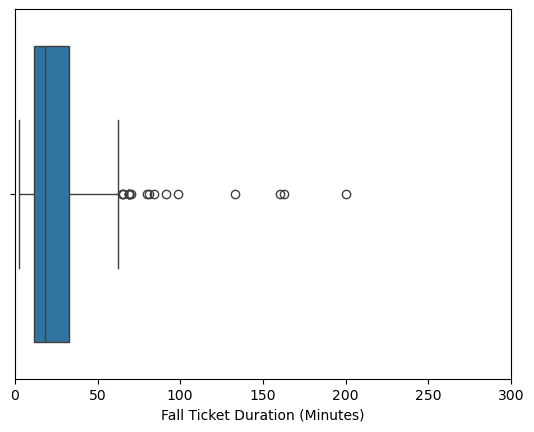

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=fall_clean['ticket_duration_minutes'])
plt.xlabel("Fall Ticket Duration (Minutes)")
plt.xlim(0, 300)

Text(0.5, 0, 'Spring Ticket Duration (Minutes)')

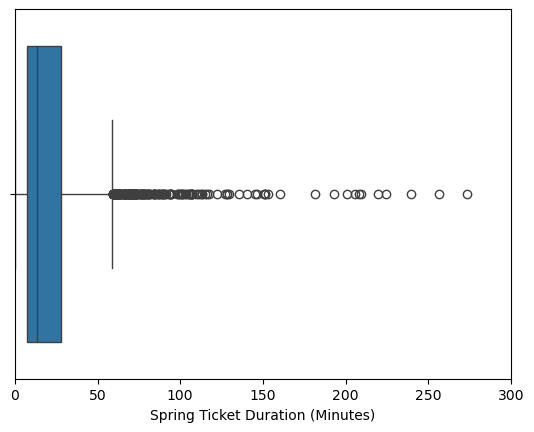

In [13]:
sns.boxplot(x=spring_clean['ticket_duration_minutes'])
plt.xlim(0, 300)
plt.xlabel("Spring Ticket Duration (Minutes)")

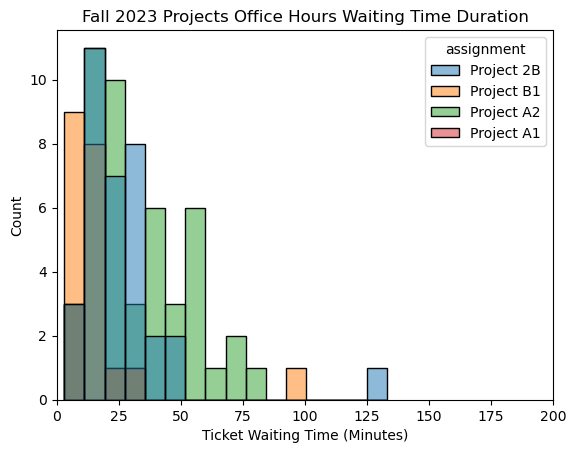

In [14]:
projects_fall = fall_clean[(fall_clean["assignment"] == "Project A1")|(fall_clean["assignment"] == "Project A2")|(fall_clean["assignment"] == "Project B1")|(fall_clean["assignment"] == "Project 2B")]
sns.histplot(data = projects_fall, hue= "assignment", x="ticket_duration_minutes", stat="count")
plt.xlim(0,200)
plt.xlabel("Ticket Waiting Time (Minutes)")
plt.title("Fall 2023 Projects Office Hours Waiting Time Duration");
#plt.legend()
#plt.show()

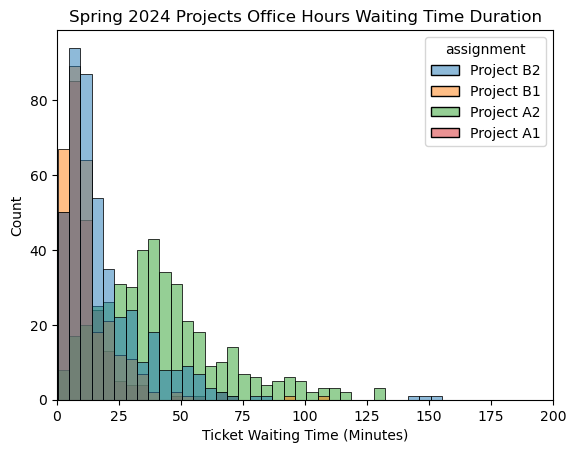

In [15]:
projects_spring = spring_clean[(spring_clean["assignment"] == "Project A1")|(spring_clean["assignment"] == "Project A2")|(spring_clean["assignment"] == "Project B1")|(spring_clean["assignment"] == "Project B2")]
sns.histplot(data = projects_spring, hue= "assignment", x="ticket_duration_minutes", stat="count")
plt.xlim(0,200);
plt.title("Spring 2024 Projects Office Hours Waiting Time Duration")
plt.xlabel("Ticket Waiting Time (Minutes)");